In [7]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import os
import sys
import pickle
from copy import deepcopy

from GroupMultiNeSS.MASE import MASE
from GroupMultiNeSS.data_generation import GroupLatentPositionGenerator
from GroupMultiNeSS.utils import mean_frobenius_error, frobenius_error, make_group_indices
from GroupMultiNeSS.group_multiness import GroupMultiNeSS, GroupMultiNeSSCV, OracleGroupMultiNeSS
from GroupMultiNeSS.multiness import MultiNeSS, MultiNeSSCV


sys.path.append(os.path.abspath(".."))
from utils.plot_utils import plot_errors

## Change n

In [11]:
n_range = [200, 300, 400, 500]
M = 16
K = 4
s_vw = 0.1
s_wu = 0.1
s_vu = 0.1

edge_distrib = "bernoulli"
loops_allowed=True

d = 3
d_shared = d
d_groups=np.array([d] * K)
d_individs =np.array([d] * M)

group_props = np.ones(K) / K
group_indices = make_group_indices(group_props, M)

In [13]:
init_kwargs = {"edge_distrib": edge_distrib, "loops_allowed": loops_allowed, "sigmas": None, 
               "max_rank": 2 * d}
fit_kwargs = {"lr": 3., "tol": 1e-5, "verbose": False, "verbose_interval": 10, "max_iter": 500}

In [10]:
errP = {"GroupMultiNeSS": [], "Non-convex Oracle": [], "MultiNeSS": [],  "COSIE": []}
errS = {"GroupMultiNeSS": [], "Non-convex Oracle": [], "MultiNeSS": [],   }
errQ = {"GroupMultiNeSS": [], "Non-convex Oracle": []}
errR = {"GroupMultiNeSS": [],  "Non-convex Oracle": [], "MultiNeSS": [],}

In [3]:
for n in n_range:
    print(f"Started working with n={n}!")
    
    lpg = GroupLatentPositionGenerator(n_nodes=n, 
                                       n_layers=M, 
                                       s_vw=s_vw, s_wu=s_wu, s_vu=s_vu, 
                                       group_indices=group_indices,
                                       edge_distrib=edge_distrib, 
                                       loops_allowed=loops_allowed,
                                       noise_sigma=1,
                                       d_shared=d_shared,
                                       d_individs=d_individs,
                                       d_groups=d_groups)


    lpg.generate(random_seed=1)
    As, Ps, S_true, Qs_true, Rs_true = lpg.As, lpg.Ps, lpg.S, lpg.Qs, lpg.Rs

    print("MASE")
    Ps_mase, _, _ = MASE(As, d_shared=d_shared + np.sum(d_groups) + np.sum(d_individs),
                         d_individs=d_shared + d_individs + d_groups[group_indices])

    print("GMN Oracle")
    oracle_gmn = OracleGroupMultiNeSS(group_indices=group_indices, n_jobs=K,
                                      d_shared=d_shared, d_groups=d_groups, d_individs=d_individs,
                                      loops_allowed=loops_allowed, edge_distrib=edge_distrib)
    oracle_gmn.fit(As, **fit_kwargs)
    
    
    print("MN")
    multiness = MultiNeSSCV(cv_folds=3, fix_layer_split=True, **init_kwargs)
    # multiness = MultiNeSS(**init_kwargs)
    multiness.fit(As, refit=True, **fit_kwargs)
    

    
    print("GMN")
    group_multiness_refit = GroupMultiNeSSCV(group_indices=group_indices, cv_folds=3, 
                                             fix_layer_split=True, **init_kwargs)
    # group_multiness_refit = GroupMultiNeSS(group_indices=group_indices, n_jobs=K, **init_kwargs)
    group_multiness_refit.fit(As, refit=True, **fit_kwargs)
    print(multiness.make_final_error_report(S_true, Qs_true[lpg.group_indices] + Rs_true, Ps=Ps))
    print(group_multiness_refit.make_final_error_report(S_true, Qs_true, Rs_true, Ps=Ps))
    
    Ps_mn = multiness.compute_expected_adjacency()
    S_mn, Rs_mn = multiness.get_all_fitted_matrices_by_type()
    
    Ps_gmn_refit = group_multiness_refit.compute_expected_adjacency()
    S_gmn_refit, Qs_gmn_refit, Rs_gmn_refit = group_multiness_refit.get_all_fitted_matrices_by_type()
    
    Ps_gmn_oracle = oracle_gmn.compute_expected_adjacency()
    S_gmn_oracle, Qs_gmn_oracle, Rs_gmn_oracle = oracle_gmn.get_all_fitted_matrices_by_type()

    
    errP["MultiNeSS"].append(mean_frobenius_error(Ps, Ps_mn, relative=True))
    errP["GroupMultiNeSS"].append(mean_frobenius_error(Ps, Ps_gmn_refit, relative=True))
    errP["Non-convex Oracle"].append(mean_frobenius_error(Ps, Ps_gmn_oracle, relative=True))
    errP["COSIE"].append(mean_frobenius_error(Ps, Ps_mase, relative=True))
    
    errS["MultiNeSS"].append(frobenius_error(S_true, S_mn, relative=True))
    errS["GroupMultiNeSS"].append(frobenius_error(S_true, S_gmn_refit, relative=True))
    errS["Non-convex Oracle"].append(frobenius_error(S_true, S_gmn_oracle, relative=True))
    
    errQ["GroupMultiNeSS"].append(mean_frobenius_error(Qs_true, Qs_gmn_refit))
    errQ["Non-convex Oracle"].append(mean_frobenius_error(Qs_true, Qs_gmn_oracle))
    
    errR["MultiNeSS"].append(mean_frobenius_error(Rs_true, Rs_mn, relative=True))
    errR["GroupMultiNeSS"].append(mean_frobenius_error(Rs_true, Rs_gmn_refit, relative=True))
    errR["Non-convex Oracle"].append(mean_frobenius_error(Rs_true, Rs_gmn_oracle, relative=True))

with open("saved_results/n_gmn_model_compar_logistic.pkl", "wb") as f:
    err_n = {"P": errP, "S": errS, "Q": errQ, "R": errR}
    pickle.dump(err_n, f)
    

In [6]:
with open("saved_results/n_gmn_model_compar_logistic.pkl", "rb") as f:
    errP, errS, errQ, errR = pickle.load(f).values()
    

## Change M

In [4]:
n = 200
K = 4
group_props = np.ones(K) / K

edge_distrib = "bernoulli"
M_range = [16, 24, 32, 40, 48]


In [5]:
errP_M = {"GroupMultiNeSS": [], "Non-convex Oracle": [], "MultiNeSS": [],  "COSIE": []}
errS_M = {"GroupMultiNeSS": [],  "Non-convex Oracle": [], "MultiNeSS": [],  }
errQ_M = {"GroupMultiNeSS": [], "Non-convex Oracle": []}
errR_M = {"GroupMultiNeSS": [], "Non-convex Oracle": [],   "MultiNeSS": [],}

In [15]:
for M in M_range:
    print(f"Started working with M={M}!")
    d_individs = np.array([d] * M)
    d_groups=np.array([d] * K)
    group_indices = make_group_indices(group_props, M)
    d_groups_all = np.array([d_groups[idx] for idx in group_indices])
    
    lmbda_mn_range = np.sqrt(n * M) * np.array([0.01, 0.03, 0.1, 0.3, 1, 3])
    lmbda1_range = np.sqrt(n * M / K) * np.array([0.01, 0.03, 0.1, 0.3, 1, 3])
    lmbda2_range = M * np.sqrt(n / K) * np.array([0.01, 0.03, 0.1, 0.3, 1, 3])
    param_grid_gmn = {"lmbda1": lmbda1_range,  "lmbda2": lmbda2_range, }
    param_grid_mn = {"lmbda": lmbda_mn_range}
    
    lpg = GroupLatentPositionGenerator(n_nodes=n, 
                                       n_layers=M, 
                                       s_vw=s_vw,
                                       s_wu=s_wu,
                                       group_indices=group_indices,
                                       edge_distrib=edge_distrib, 
                                       d_shared=d_shared,
                                       d_individs=d_individs,
                                       d_groups=d_groups)


    lpg.generate(random_seed=1)
    As, Ps, S_true, Qs_true, Rs_true = lpg.As, lpg.Ps, lpg.S, lpg.Qs, lpg.Rs 
    
    print("MASE")
    Ps_mase, _, _ = MASE(As, d_shared=d_shared + np.sum(d_groups) + np.sum(d_individs),
                         d_individs=d_shared + d_individs + d_groups[group_indices])


    print("GMN Oracle")
    oracle_gmn = OracleGroupMultiNeSS(group_indices=group_indices, n_jobs=K,
                                      d_shared=d_shared, d_groups=d_groups, d_individs=d_individs,
                                      loops_allowed=loops_allowed, edge_distrib=edge_distrib)
    oracle_gmn.fit(As, **fit_kwargs)

    
    print("MN")
    multiness = MultiNeSSCV(param_grid=param_grid_mn, cv_folds=3, fix_layer_split=True, **init_kwargs)
    # multiness = MultiNeSS(**init_kwargs)
    multiness.fit(As, refit=True, **fit_kwargs)

    
    print("GMN+")
    group_multiness_refit = GroupMultiNeSSCV(group_indices=group_indices, 
                                             param_grid=param_grid_gmn,
                                             alpha1 = 2 * np.ones(M) / np.sqrt(M / K),
                                             alpha2 = 2 * np.ones(K) / np.sqrt(K),
                                             cv_folds=3, 
                                             fix_layer_split=True, **init_kwargs)
    # group_multiness_refit = GroupMultiNeSS(group_indices=group_indices, n_jobs=K, **init_kwargs)
    group_multiness_refit.fit(As, refit=True, **fit_kwargs)
    group_multiness_refit.plot_cv_results()
    
    
    # Compute Errors
    Ps_mn = multiness.compute_expected_adjacency()
    S_mn, Rs_mn = multiness.get_all_fitted_matrices_by_type()
    
    Ps_gmn_refit = group_multiness_refit.compute_expected_adjacency()
    S_gmn_refit, Qs_gmn_refit, Rs_gmn_refit = \
        group_multiness_refit.get_all_fitted_matrices_by_type()
    
    Ps_gmn_oracle = oracle_gmn.compute_expected_adjacency()
    S_gmn_oracle, Qs_gmn_oracle, Rs_gmn_oracle = oracle_gmn.get_all_fitted_matrices_by_type()
    
    print(multiness.make_final_error_report(S_true, Qs_true[lpg.group_indices] + Rs_true, Ps=Ps))
    print(group_multiness_refit.make_final_error_report(S_true, Qs_true, Rs_true, Ps=Ps))
    
    errP_M["MultiNeSS"].append(mean_frobenius_error(Ps, Ps_mn, relative=True))
    errP_M["GroupMultiNeSS"].append(mean_frobenius_error(Ps, Ps_gmn_refit, relative=True))
    errP_M["Non-convex Oracle"].append(mean_frobenius_error(Ps, Ps_gmn_oracle, relative=True))
    errP_M["COSIE"].append(mean_frobenius_error(Ps, Ps_mase, relative=True))
    
    errS_M["MultiNeSS"].append(frobenius_error(S_true, S_mn, relative=True))
    errS_M["GroupMultiNeSS"].append(frobenius_error(S_true, S_gmn_refit, relative=True))
    errS_M["Non-convex Oracle"].append(frobenius_error(S_true, S_gmn_oracle, relative=True))
    
    errQ_M["GroupMultiNeSS"].append(mean_frobenius_error(Qs_true, Qs_gmn_refit))
    errQ_M["Non-convex Oracle"].append(mean_frobenius_error(Qs_true, Qs_gmn_oracle))
    
    errR_M["MultiNeSS"].append(mean_frobenius_error(Rs_true + Qs_true[lpg.group_indices], Rs_mn, relative=True))
    errR_M["GroupMultiNeSS"].append(mean_frobenius_error(Rs_true, Rs_gmn_refit, relative=True))
    errR_M["Non-convex Oracle"].append(mean_frobenius_error(Rs_true, Rs_gmn_oracle, relative=True))
    
with open("saved_results/m_gmn_model_compar_logistic.pkl", "wb") as f:
    err_M = {"P": errP_M, "S": errS_M, "Q": errQ_M, "R": errR_M}
    pickle.dump(err_M, f)

In [ ]:
with open("saved_results/m_gmn_model_compar_logistic.pkl", "rb") as f:
    errP_M, errS_M, errQ_M, errR_M = pickle.load(f).values()
    

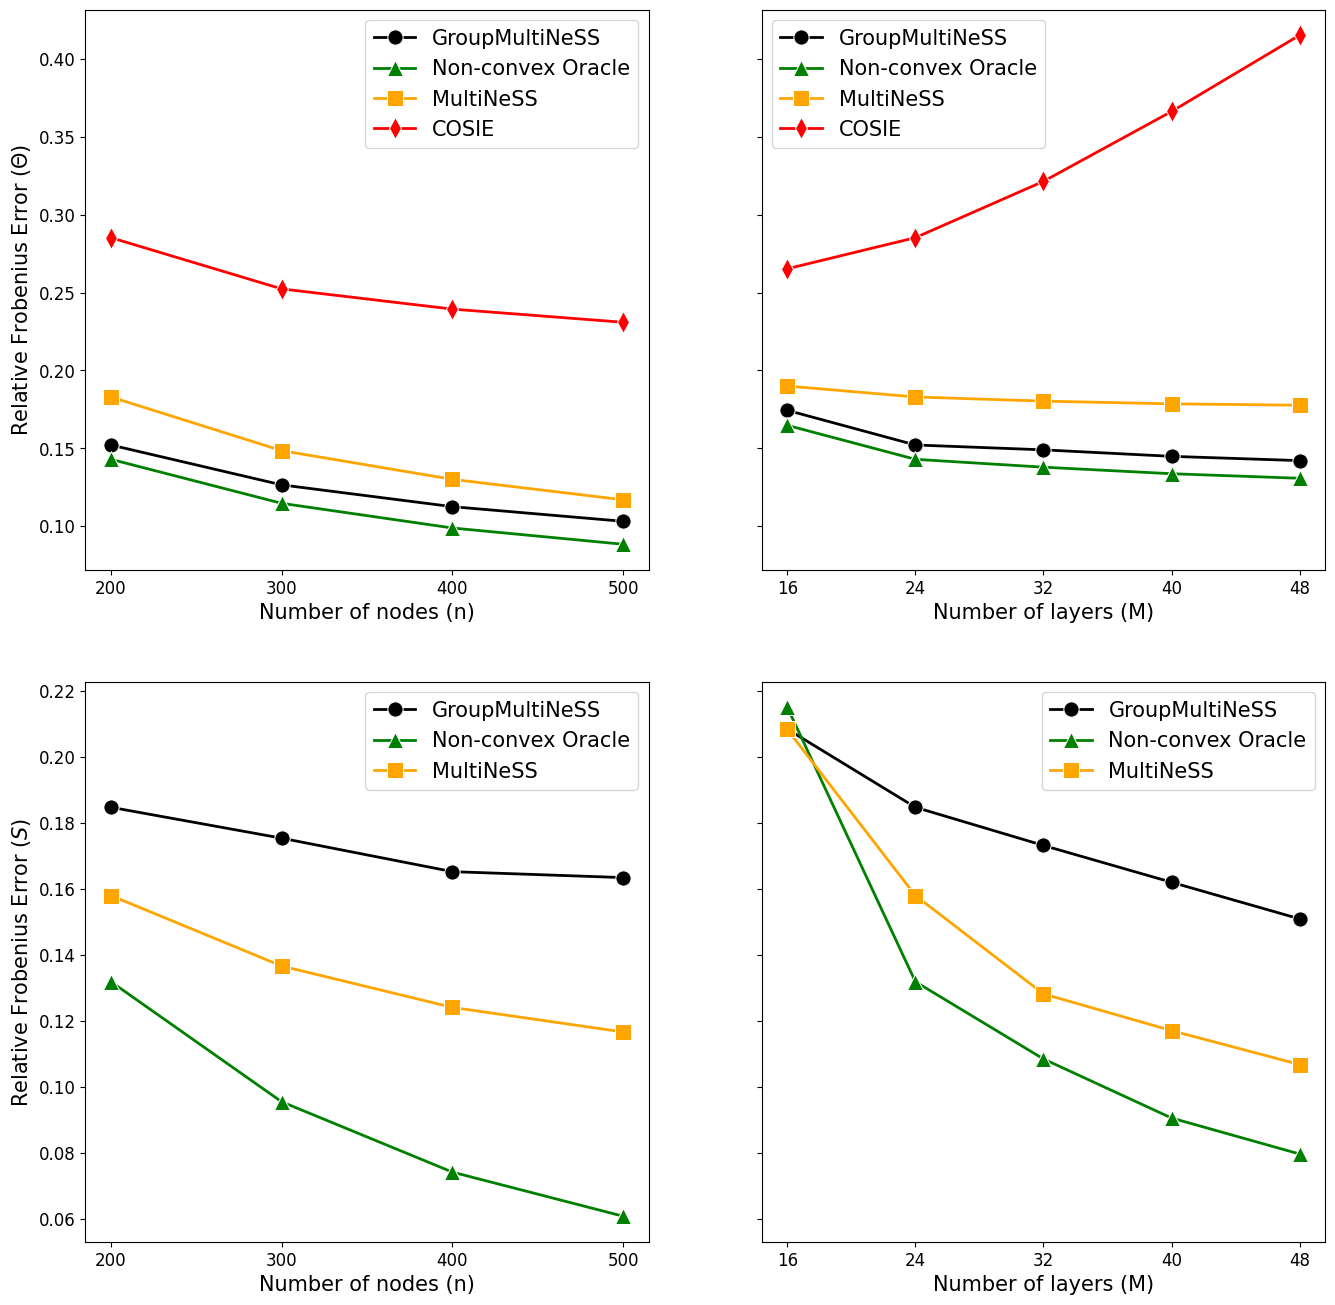

In [28]:
fig, axs = plt.subplots(2, 2, sharey=True, figsize=(16, 16))
plot_errors(err_dict=errP, x_range=n_range, 
            ylabel="Relative Frobenius Error ($\Theta$)",
            xlabel="Number of nodes (n)", ax=axs[0, 0])
plot_errors(err_dict=errP_M, x_range=M_range, 
            ylabel="Relative Frobenius Error ($\Theta$)",
            xlabel="Number of layers (M)", ax=axs[0, 1])

plot_errors(err_dict=errS, x_range=n_range, 
            ylabel="Relative Frobenius Error ($S$)",
            xlabel="Number of nodes (n)", ax=axs[1, 0])

plot_errors(err_dict=errS_M, x_range=M_range, 
            ylabel="Relative Frobenius Error ($S$)",
            xlabel="Number of layers (M)", ax=axs[1, 1])

plt.savefig("Figures/m_n_errors_gmn_model_compar_logistic.pdf", dpi=200)